In [153]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_445732660_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_445732660_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\lightkurve\config\__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to C:\Users\SL\.lightkurve\cache. Please move all the files in the legacy directory C:\Users\SL\.lightkurve-cache to the new location and remove the legacy directory. Refer to https://lightkurve.github.io/lightkurve/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<IPython.core.display.Javascript object>

# TIC 445732660 Analysis (EA)

- new VSX entry


## TESS Data

In [2]:
tic = 445732660

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["QLP", ])  # prefer QLP data for uniiformity
# sr = sr[np.isin(sr.author, ["SPOC", "TESS-SPOC"])]  # for uniformity, only 1 sector (98) with QLP-only data 
sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 09,2019,QLP,1800,445732660,0.0,N/A
1,TESS Sector 10,2019,QLP,1800,445732660,0.0,N/A
2,TESS Sector 62,2023,QLP,200,445732660,0.0,N/A
3,TESS Sector 63,2023,QLP,200,445732660,0.0,N/A
4,TESS Sector 89,2025,QLP,200,445732660,0.0,N/A
5,TESS Sector 90,2025,QLP,200,445732660,0.0,N/A
6,TESS Sector 99,2026,QLP,600,445732660,0.0,N/A


LightCurveCollection of 7 objects:
    0: <TessLightCurve LABEL="TIC 445732660" SECTOR=9 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    1: <TessLightCurve LABEL="TIC 445732660" SECTOR=10 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    2: <TessLightCurve LABEL="TIC 445732660" SECTOR=62 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    3: <TessLightCurve LABEL="TIC 445732660" SECTOR=63 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    4: <TessLightCurve LABEL="TIC 445732660" SECTOR=89 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    5: <TessLightCurve LABEL="TIC 445732660" SECTOR=90 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    6: <TessLightCurve LABEL="TIC 445732660" SECTOR=99 AUTHOR=QLP FLUX_ORIGIN=sap_flux>

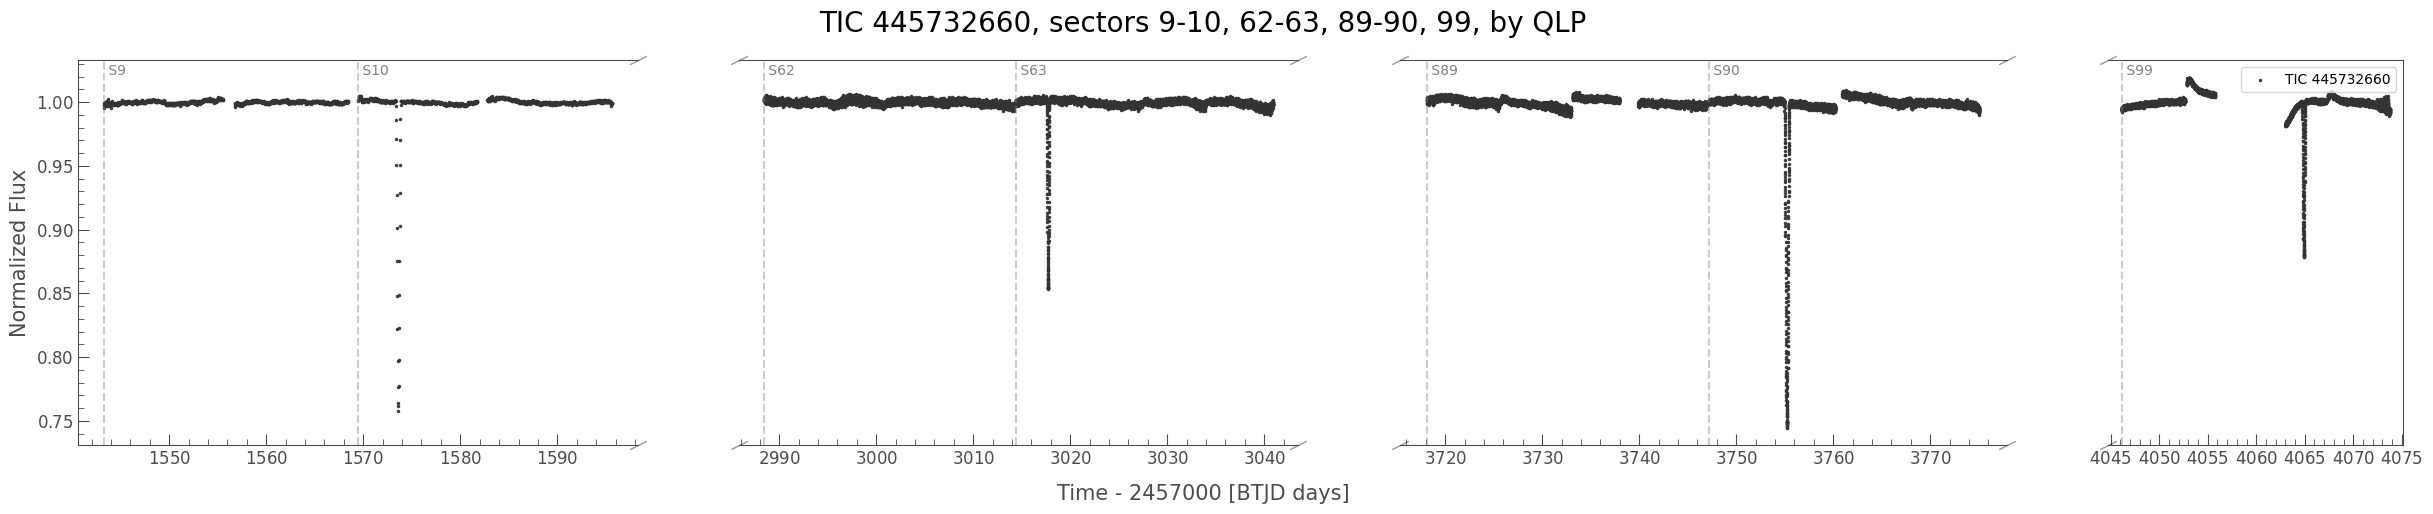

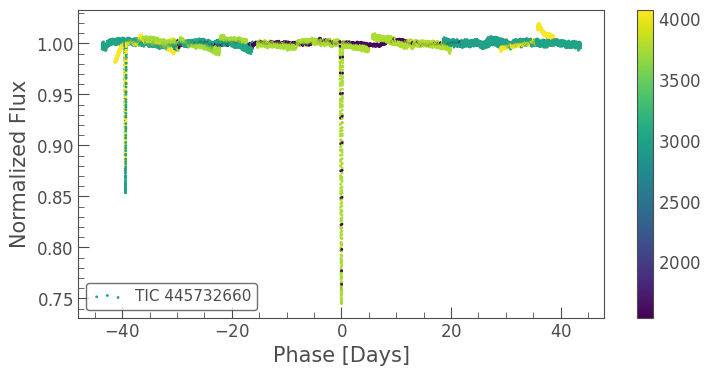

In [3]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.97, 1.01) for ax in axs];


_lc_f = _lc.fold(period=87.266, epoch_time=Time(3755.225, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
# ax.set_ylim(0.97, 1.01);
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

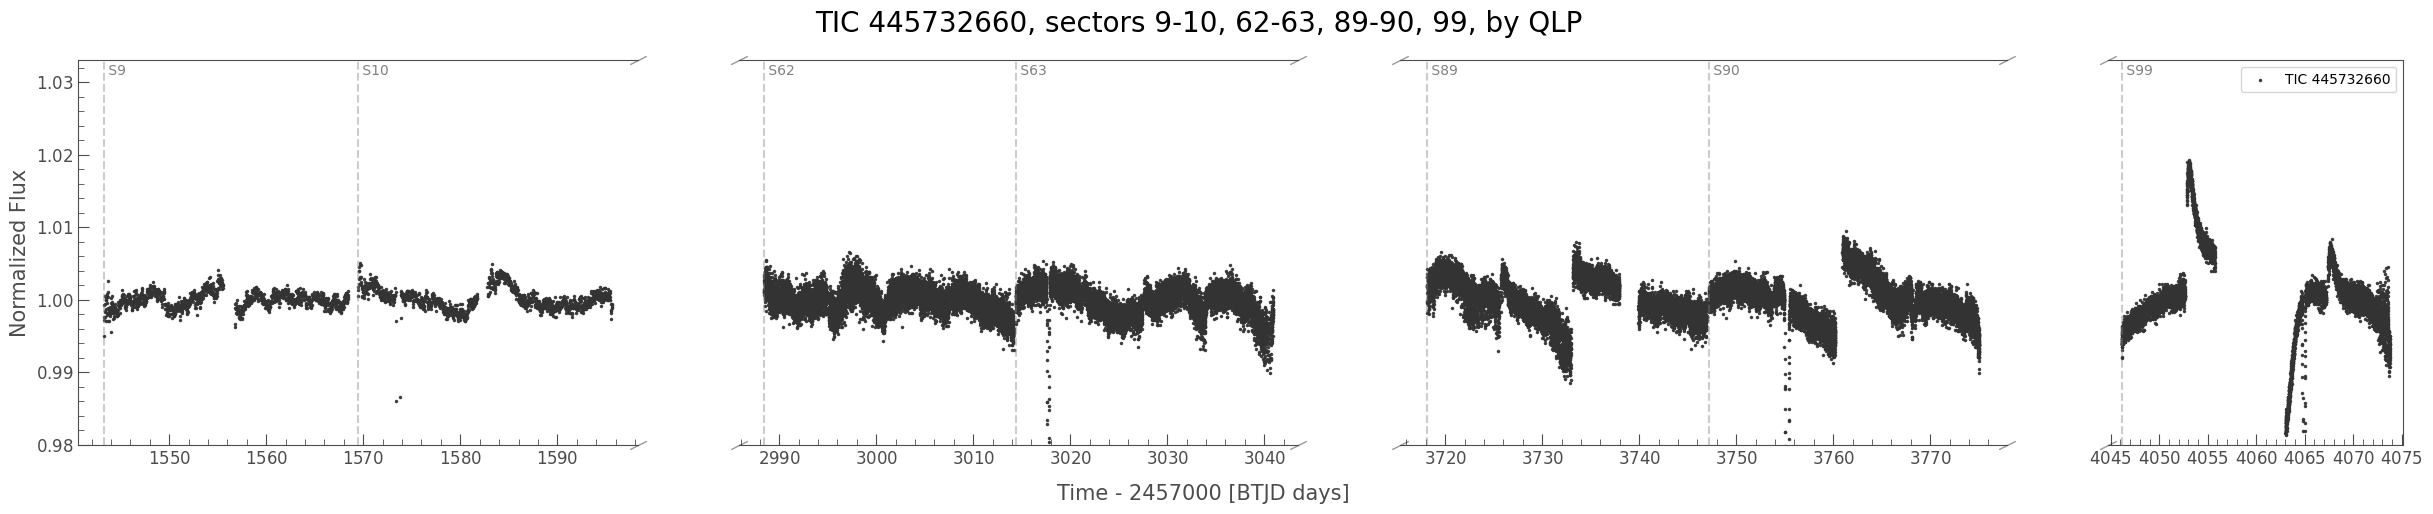

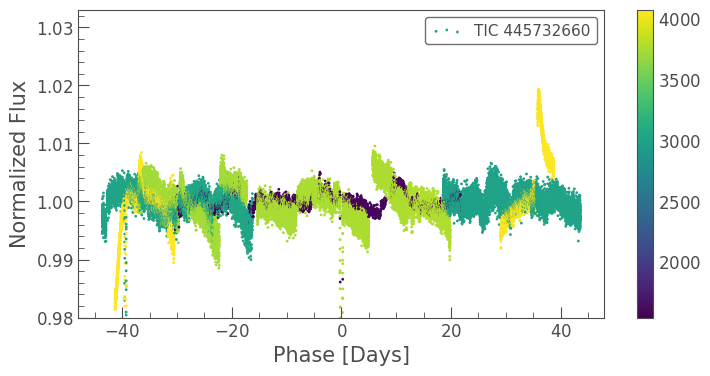

In [4]:
# truncating the eclipses to see out of eclipse variation

_ylim = (0.98, None)
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
[ax.set_ylim(*_ylim) for ax in axs];

ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(*_ylim);

## Gaia DR3 info (coordinate, etc.)

In [5]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


In [6]:
primary_name = f"TIC {tic}" # bright star but has no HD name, probably due to the brighter nearby star
print(primary_name)

TIC 445732660


## Combining all data (TESS only)

- ASAS-3 : data does not have the photometric precision 
  - https://www.astrouw.edu.pl/cgi-asas/asas_variable/094842-5058.4,asas3,87.266,-5426.4,500,900,0
  - only 4 data points in Min I, not exactly useful


In [ ]:
# ASAS-3 data: not used

# import lightkurve_ext_readers as lker

# _lc = lker.read_asas3("http://www.astrouw.edu.pl/cgi-asas/asas_cgi_get_data?094842-5058.4,asas3")
# tplt.scatter(_lc);
# _lc = _lc.truncate(10.0, None, column="flux");
# tplt.scatter(_lc);

# lc_asas3 = _lc


### TESS: convert to mag and HJD (no systemaitcs removal)

- there are varioous out-of-eclipse variation that appears to be systematics (trend similar to background, disccontinous jumps around data gaps, especially momentum dumps)
- removad a few obvious ones initially, but found the resulting lightcurve remained to have sections that are likely to be systematics-distorted but hard to make a cutoff point.
- so skip all systematics removal instead



In [18]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

In [144]:
# of_sector(lcc_tess, 99).select_flux("sap_bkg").truncate(None, 44000, column="flux").scatter();
# of_sector(lcc_tess, 99).select_flux("sap_flux").truncate(0.97, None, column="flux").scatter();

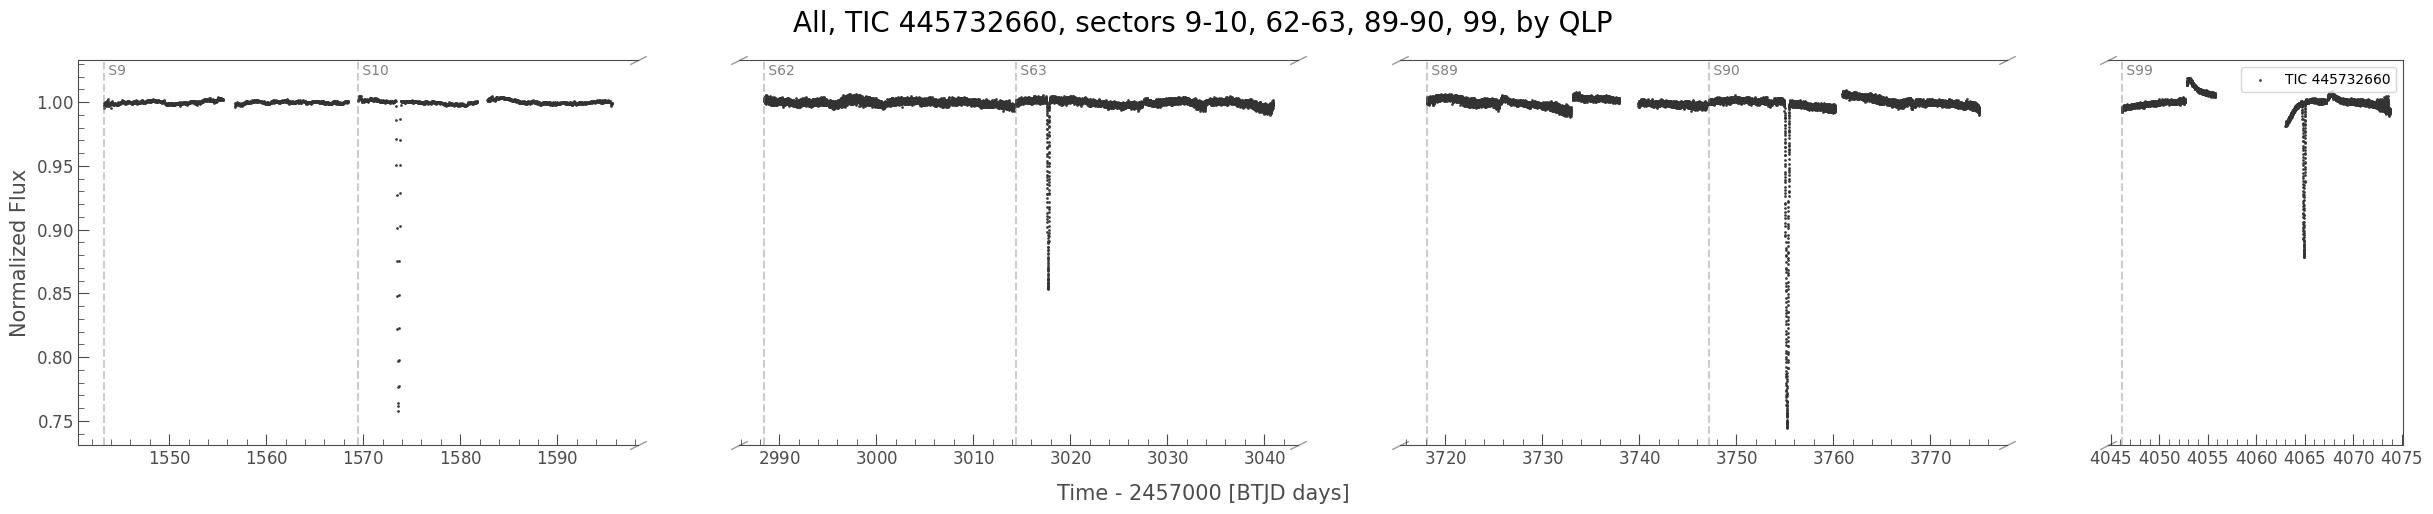

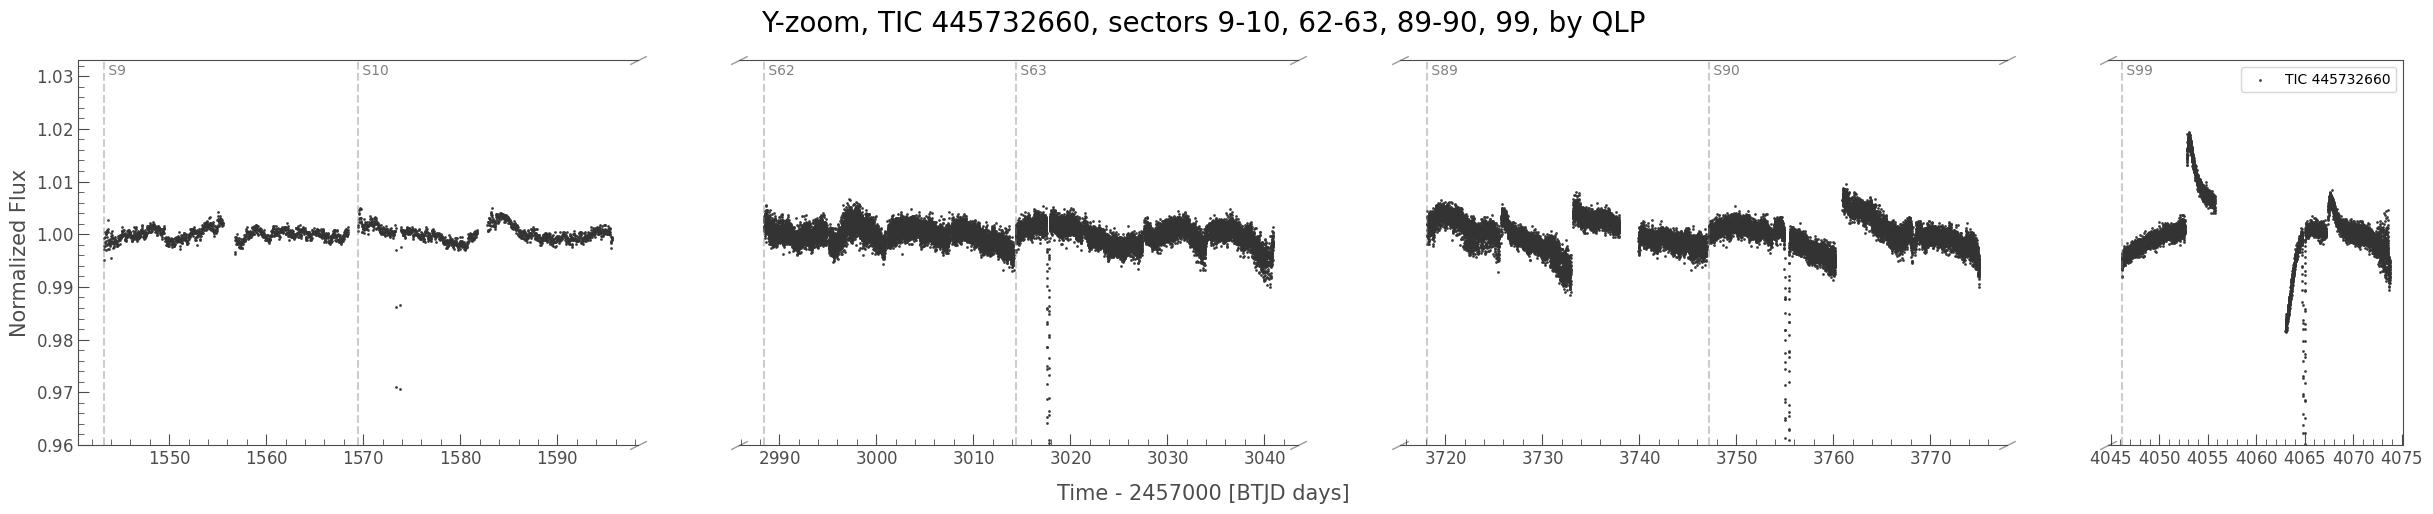

In [94]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"All, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=4, alpha=0.9);
axs[0].get_figure().suptitle(f"Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.96, None) for ax in axs];


In [125]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

# NOTES: skip the systematics removal, hard to make the right call
# for xstart, xstop in [  # scattered light, and systematics
#   (3760.9, 3769),  # S90, discontinous jump after data gap / momentum dump
#   (4052.8, 4056),   # S99, discontinous jump after data gap / momentum dump
#   (4067.3, 4068),   # S99, discontinous jump after data gap / momentum dump
# ]:
#     _lc = lke.exclude_range(_lc, xstart, xstop)

# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
# axs[0].get_figure().suptitle(f"Outliers / Systemaics removed, Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.98, None) for ax in axs];

# _lc_f = _lc.fold(period=87.266, epoch_time=Time(3755.225, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
# ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);


# convert to mag and HJD
lc_tess = _lc

lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)

Task was destroyed but it is pending!
task: <Task pending name='Task-1358' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-1359' coro=<Kernel.shell_main() running at C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\astropy\extern\configobj\validate.py:764: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for (name, val) in zip(names, values):
Task was destroyed but it is pending!
task: <Task pending name='Task-1359' coro=<Kernel.shell_main() running at C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus4\Lib\site-packages\ipykernel

The cached HJD time in ../data/hjd/hjd_TIC_445732660_QLP_9_10_62_63_89_90_99.txt has different length. discard it.


55692

### Do Actual combining

TESS # data points: 55692


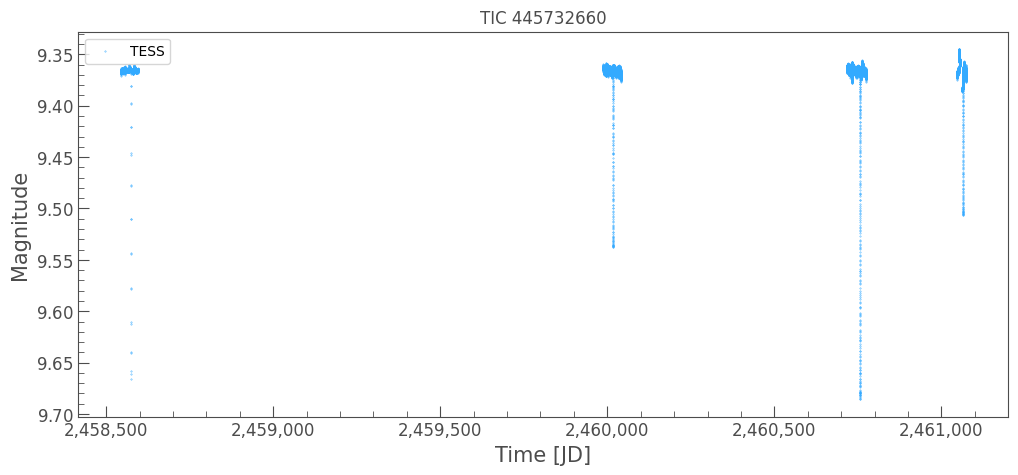

In [126]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
     # "ASAS-3": lc_asas3,
    }, 
    # shift_to="ASAS-3",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(10.4, 10.25);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  87.265 2460755.22 12.0 7.5


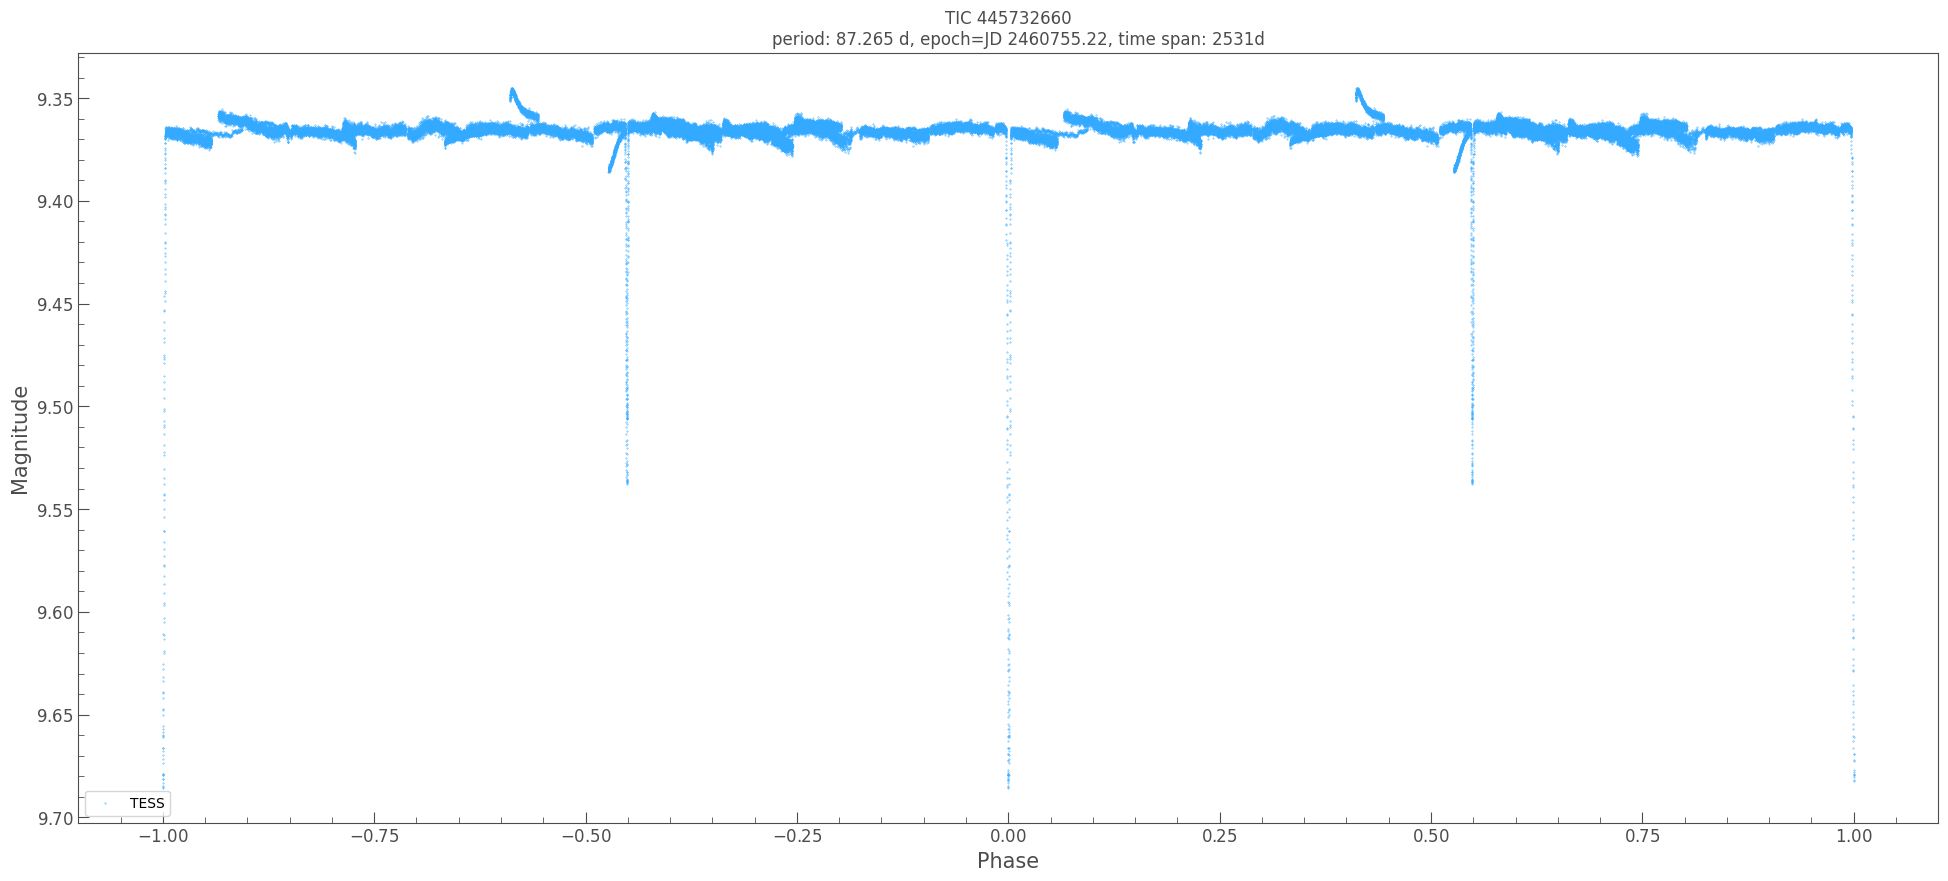

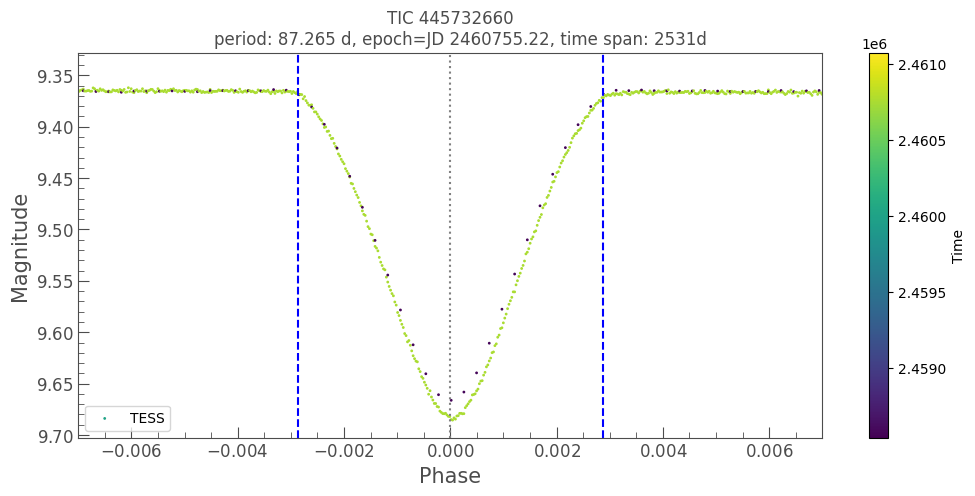

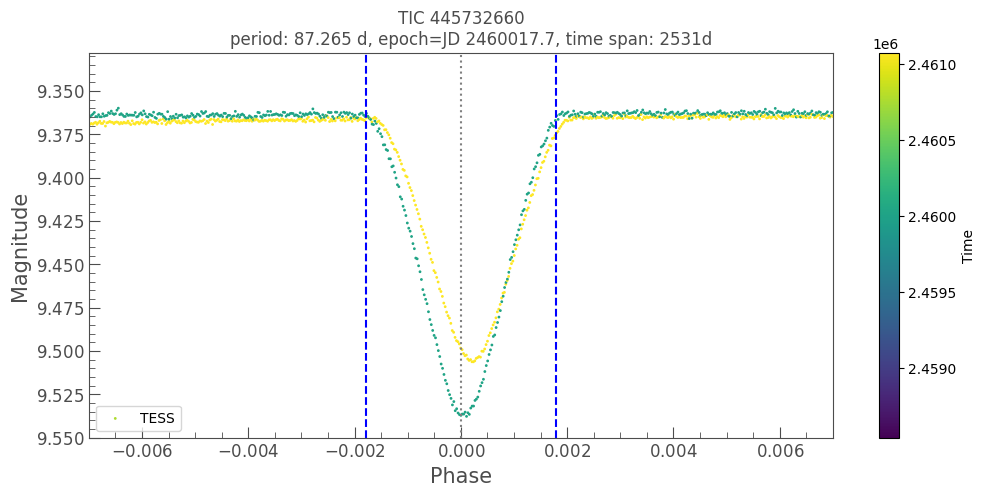

In [127]:
# reload(lkem)

# from human inspection
# epoch=3755.225, duration_hr=12.0, period=87.266, label="Min I",  # sector 90
# epoch=3017.705, duration_hr=7.5, period=87.266, label="Min II",  # sector 63
#
# period: only 2 dips for each of Min I, Min II, with multiple potential period
# - 87.26 is the only alias shared by both Min I and Min II
# - the next closest one is 114.8 (Min I) / 116 (Min II)

period_trial = 87.265
epoch_time_btjd_trial = 3755.225
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
duration_hr_min_i_trial = 12.0

epoch_time_min_ii_btjd_trial = 3017.705
epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
duration_hr_min_ii_trial = 7.5


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial, duration_hr_min_ii_trial)

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"

# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
# plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ylim_min_ii = (9.55, None)
ax.set_ylim(*ylim_min_ii);


## Period refinement with MCMC


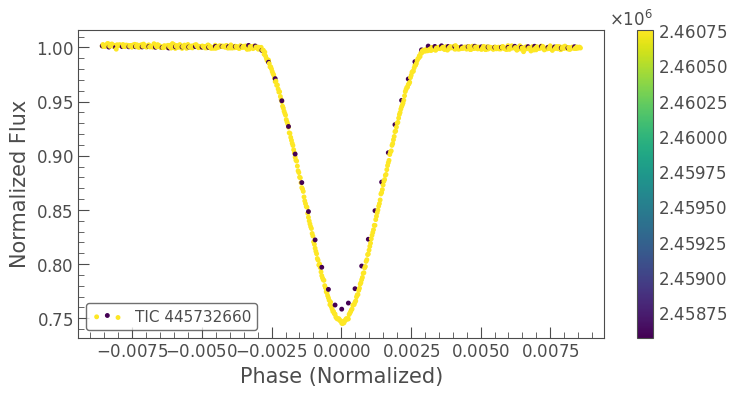

In [35]:
_lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS"), normalize=True).remove_nans()  

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 1.5) / period_trial, (0 + duration_hr_min_i_trial /24 * 1.5) / period_trial)
# lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);

In [37]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.0, -0.25, 0, 0.0013, 0.9]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.0, -0.25, 0, 0.0013, 0.9]\n\n', '…

### Final MCMC fit with the best initial period

100%|██████████| 3000/3000 [01:21<00:00, 36.62it/s]
The chain is shorter than 20 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 150;
tau: [ 56.77921159 162.79852778  94.54262525  97.51294661 186.64340755
  97.51308341]


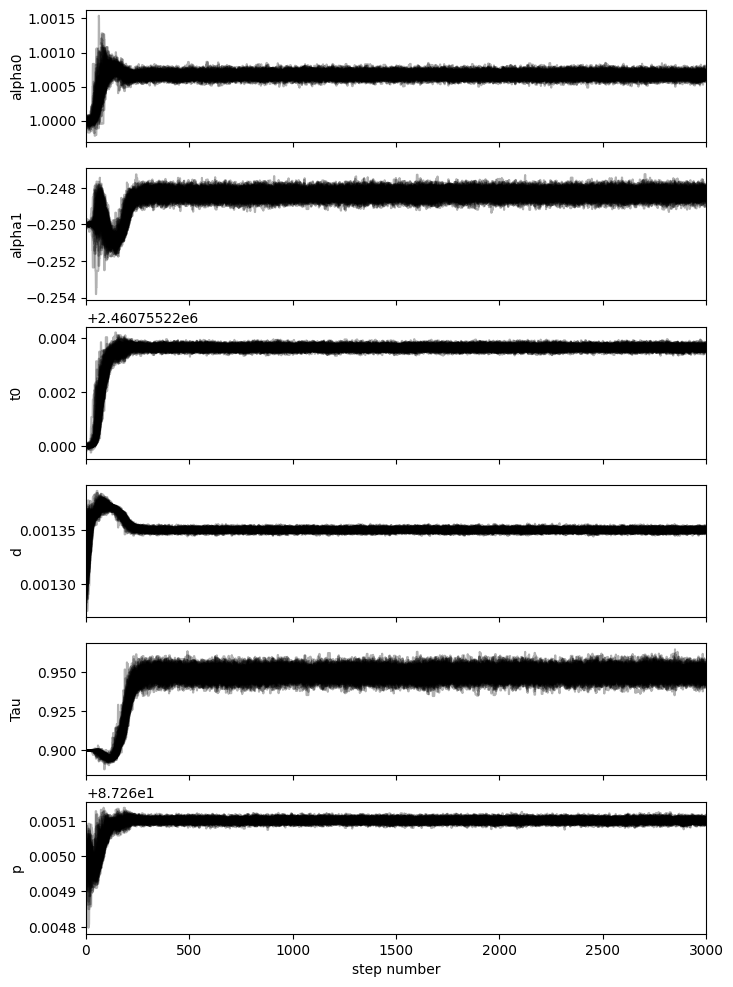

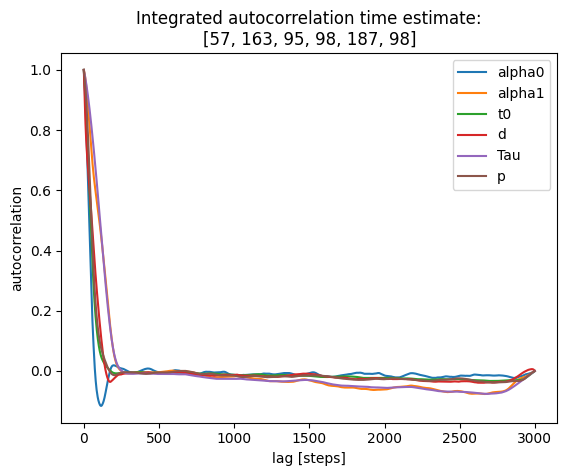

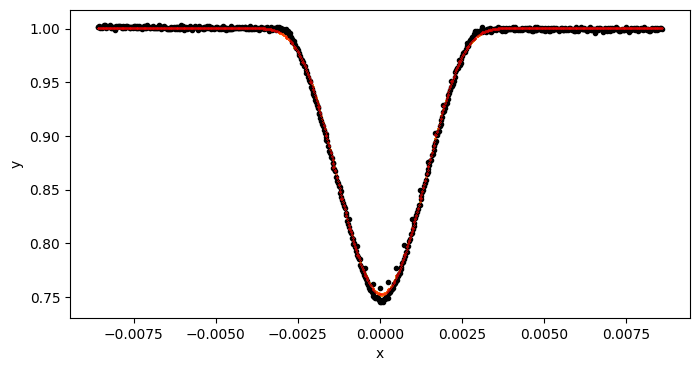

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0006712115758467, -0.24832904274711481, 2460755.2236392554, 0.001350171609871294, 0.948938669130474, 87.26510100019135
std_t0: 7.89798404042212e-05
std_p: 5.628999828146186e-06


In [39]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.0, -0.25, epoch_time_hjd_trial, 0.0013, 0.9, period_trial],
    # nruns=20, discard=1,
    nruns=3000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  87.265 2460755.224 12.0 0.5485 7.5


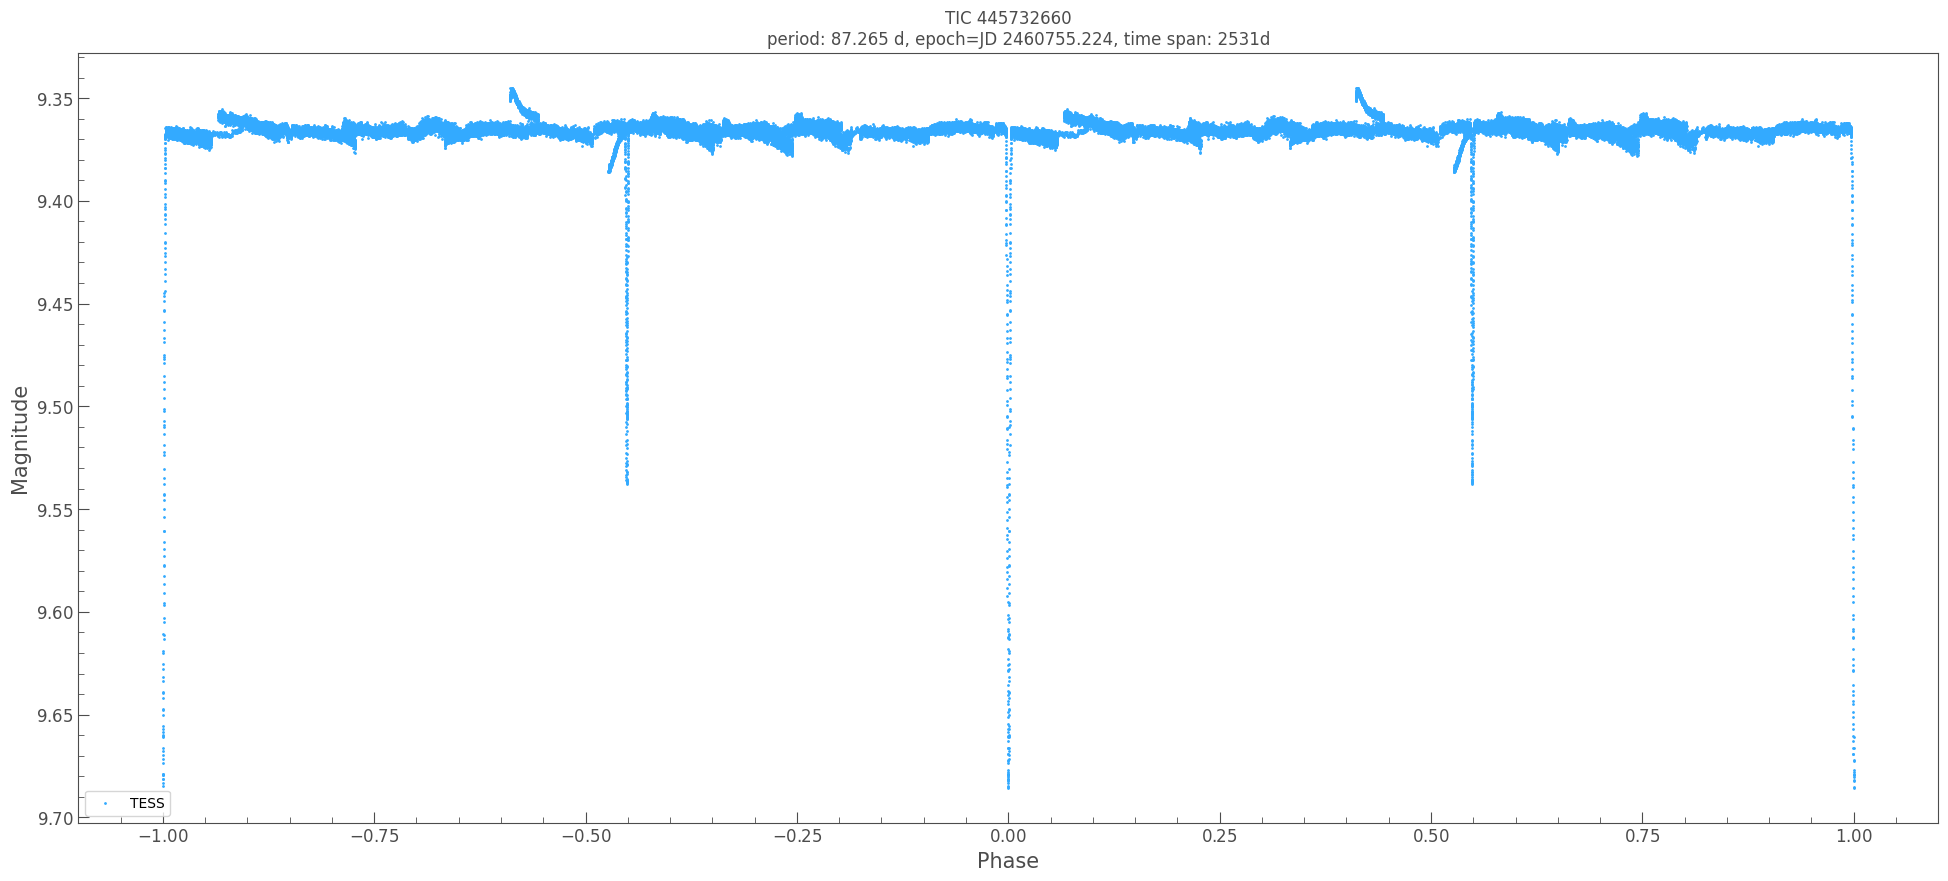

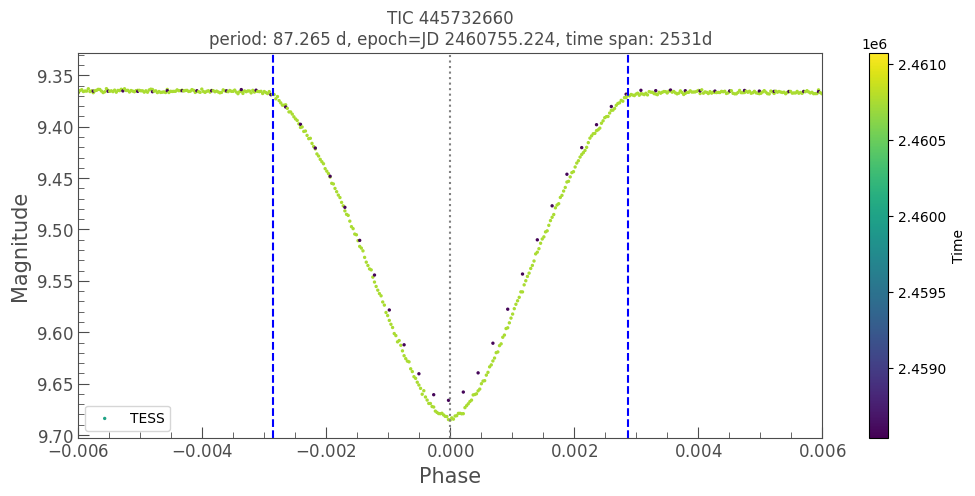

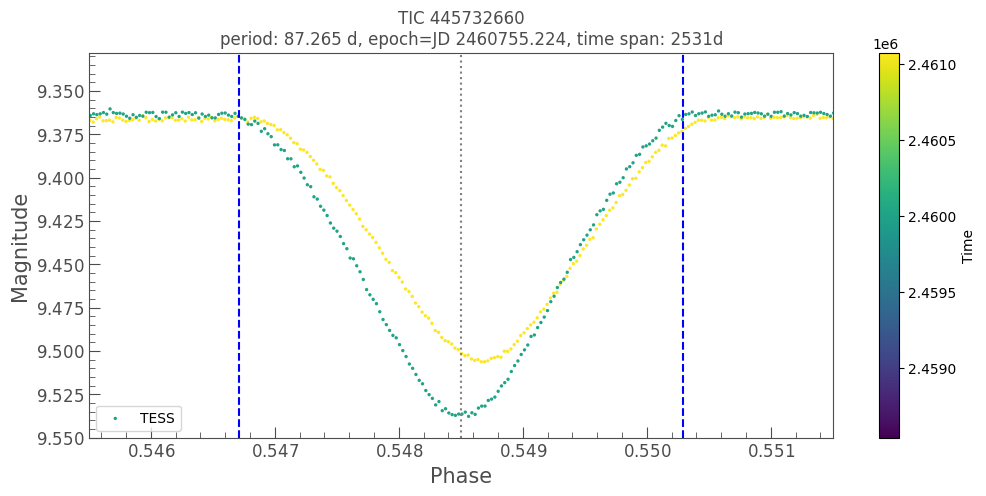

In [128]:
# reload(lkem)
from decimal import Decimal

# MCMC: p=87.26510100019135, std_p: 5.628999828146186e-06, t0=2460755.2236392554, std_t0: 7.89798404042212e-05


period_final = 87.265  # MCMC,  same as initial trial
epoch_time_hjd_final = 2460755.224  # MCMC, the 3rd digit is visible in LC
duration_hr_min_i_final = duration_hr_min_i_trial 

epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
epoch_phase_min_ii_final   = (epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, duration_hr_min_i_final,  epoch_phase_min_ii_final,  duration_hr_min_ii_final)

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1]["s"] = 1

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 2
plot_options_zoom[0][1]["c"] = "_time_"


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.006, 0.006);  # to see primary in details
ax.set_ylim(*ylim);

# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.005, 0.005), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.003, epoch_phase_min_ii_final + 0.003);  # to see secondary in details
ax.set_ylim(*ylim_min_ii);


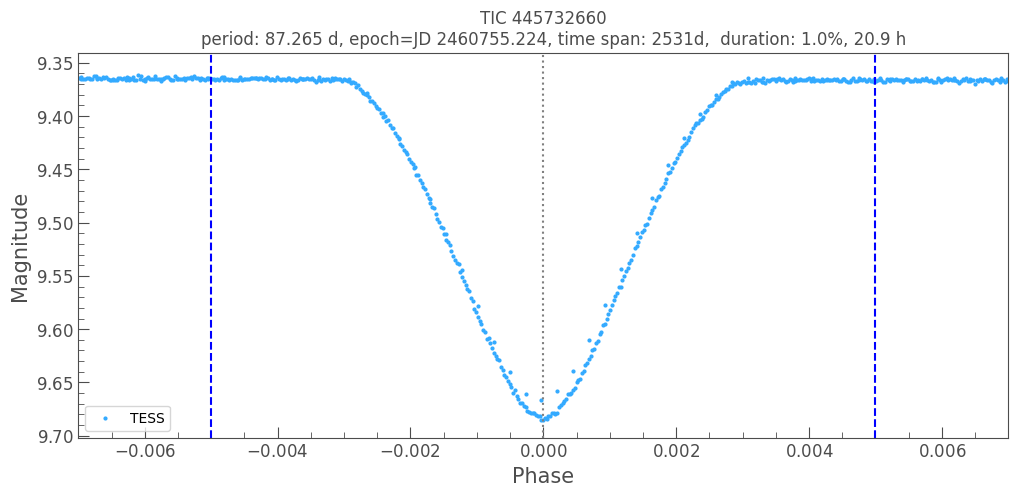

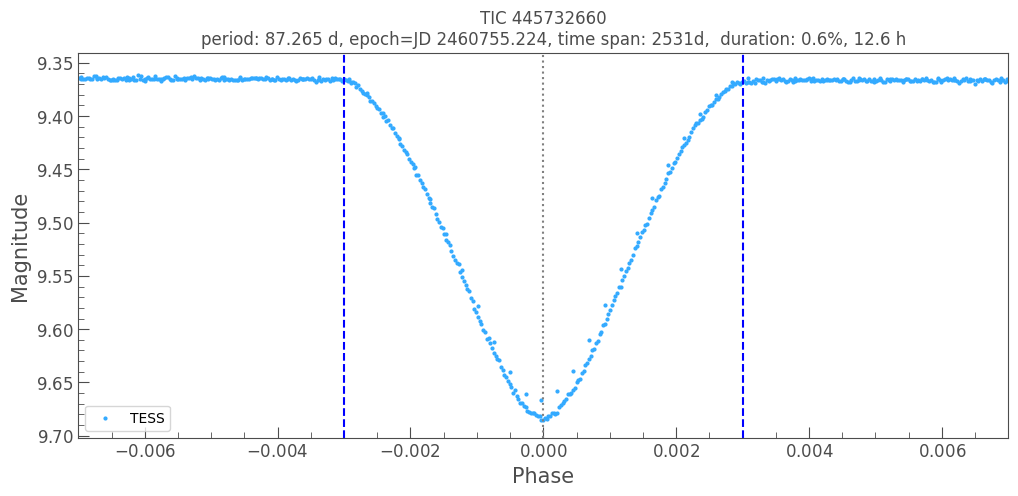

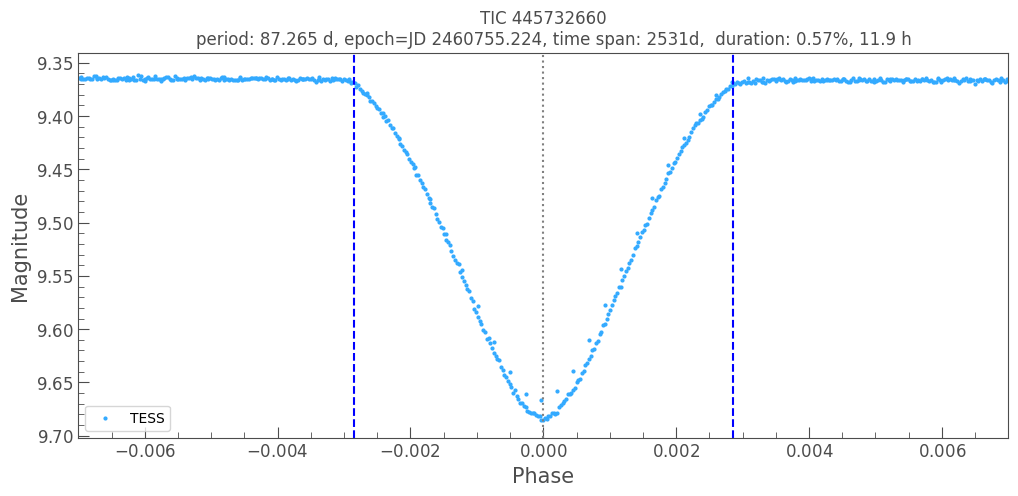

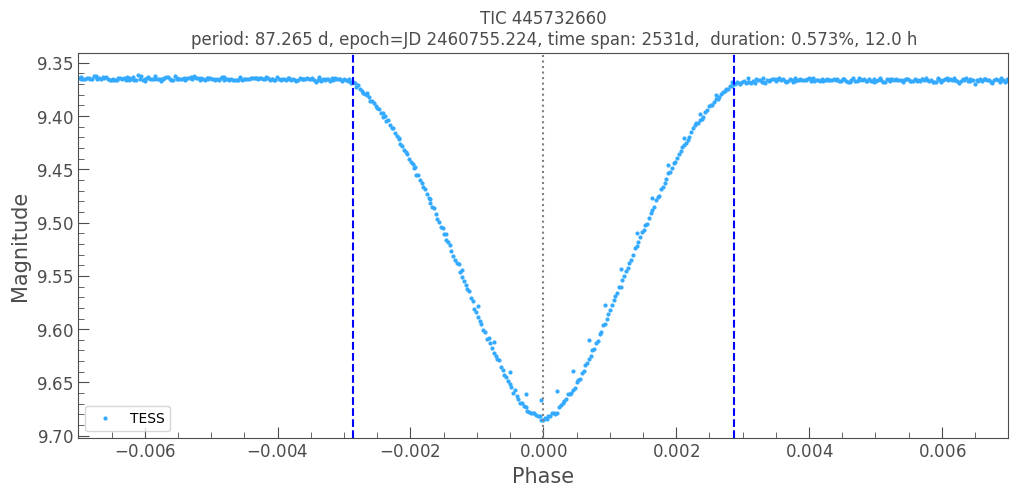

In [73]:
# demonstrate the precision difference in duration percentage 
# - 1 digit for percetnarge would be appropriate
for _precision in [0, 1, 2, 3]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / float(period_final), _precision)
    _dur_hr = _dur_pct /100 * 24 * float(period_final)
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 4
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.007, 0.007);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 10
Min II mag # num data points: 18
['9.3657', '9.6850', '9.5370']


(np.float64(0.32), np.float64(0.17))

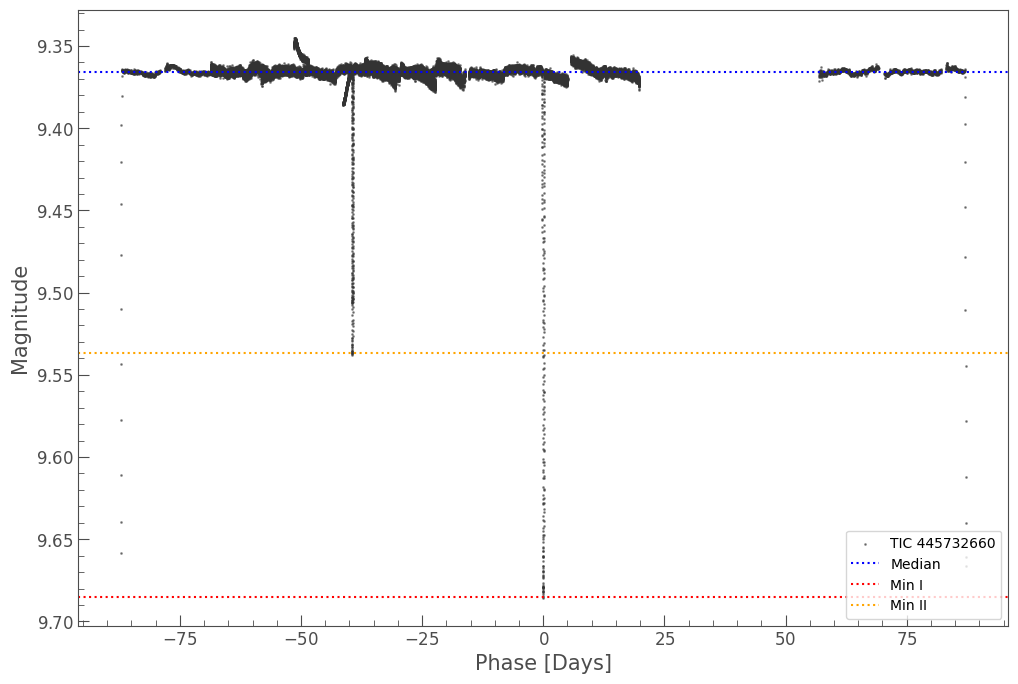

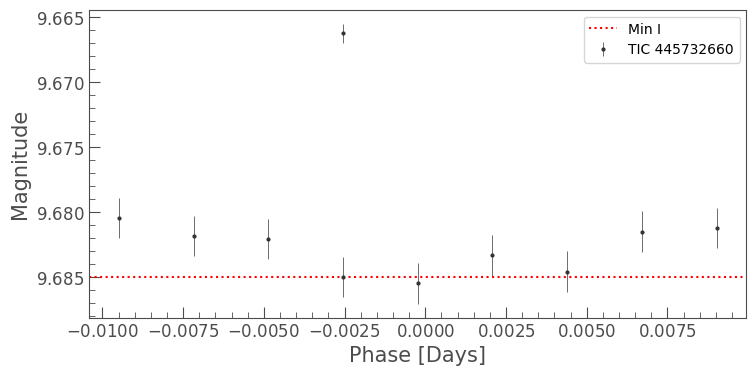

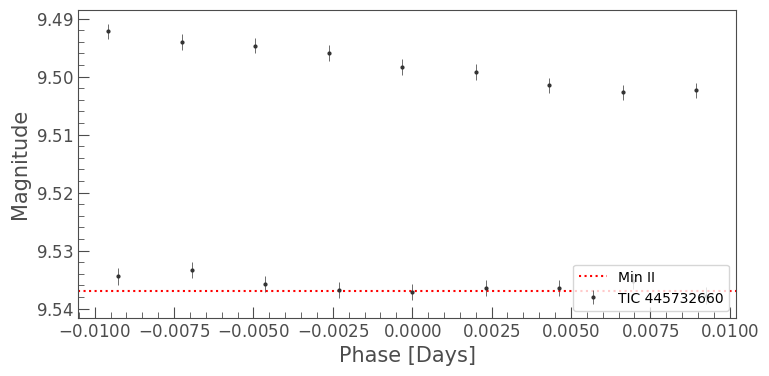

In [129]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 15 /24/60, 0 + 15 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)
# min_flux_mag = 9.675  # manual override as the mean of the Min I dips, I decided to take the deepest one, assuming there are eclipse depth variation
min_flux_mag = 9.685  # override to extrapolate the Min I of the deeper one, assuming there are eclipse depth variation


lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 15 /24/60, 0 + 15 /24/ 60)
print("Min II mag # num data points:", len(lc_zoom_min_ii))
min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)
min_ii_flux_mag = 9.537  # override to extrapolate the Min II of the deeper one, assuming there are eclipse depth variation

lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag, min_ii_flux_mag]])  #


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 2)  # does not look like it has 3 digit precision given out of eclipse varation and apparent change in Min I 

amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 2)  # does not look like it has 3 digit precision given out of eclipse varation and apparent change in Min I 

(amp_min_i_flux_mag, amp_min_ii_flux_mag)  # amp_flux_mag, 

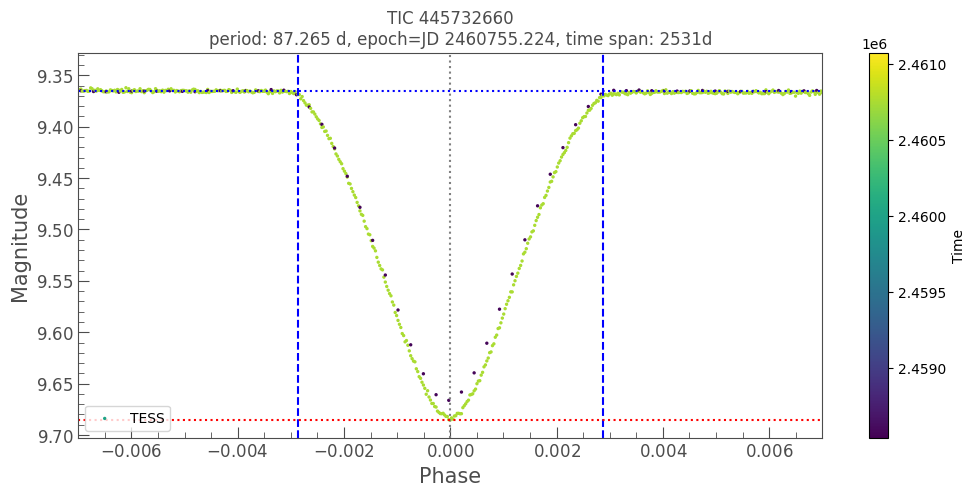

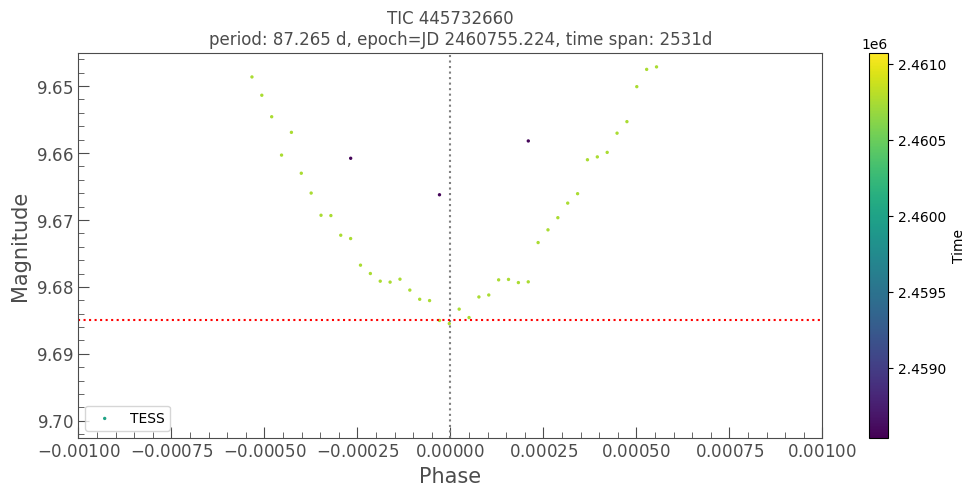

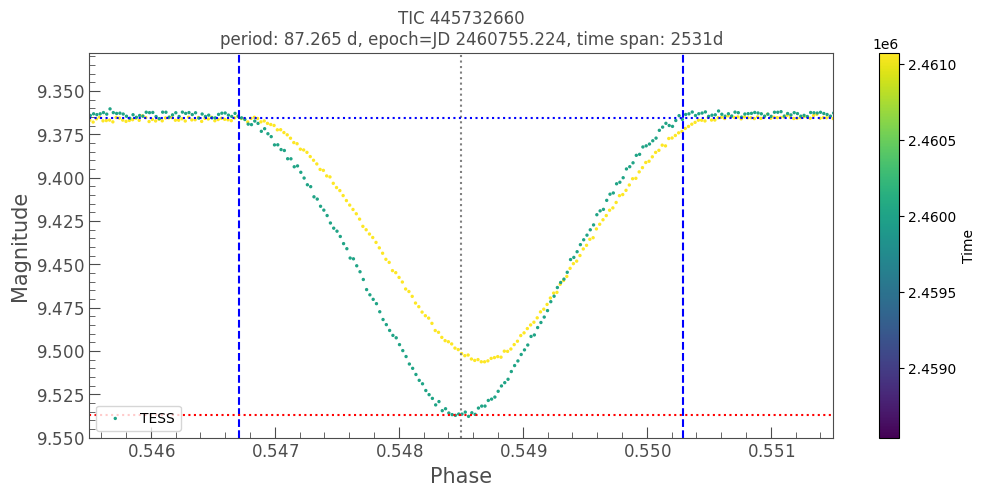

In [130]:
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.007, 0.007);  # to see primary in details
ax.set_ylim(*ylim);
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I");

# Min I further zoom
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.001, 0.001);  # to see primary in details
ax.set_ylim(None, 9.645);
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I");

# ------

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.003, epoch_phase_min_ii_final + 0.003);  # to see secondary in details
ax.set_ylim(*ylim_min_ii);
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median");
ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II");


### Maximum / Median magnitude in V 

- no GCPD data

In [79]:
median_flux_vmag = Decimal("10.18")  # from Gaia DR3, consistent with APASS value adopted by SIMBAD
median_flux_vmag

Decimal('10.18')

## Plots for VSX

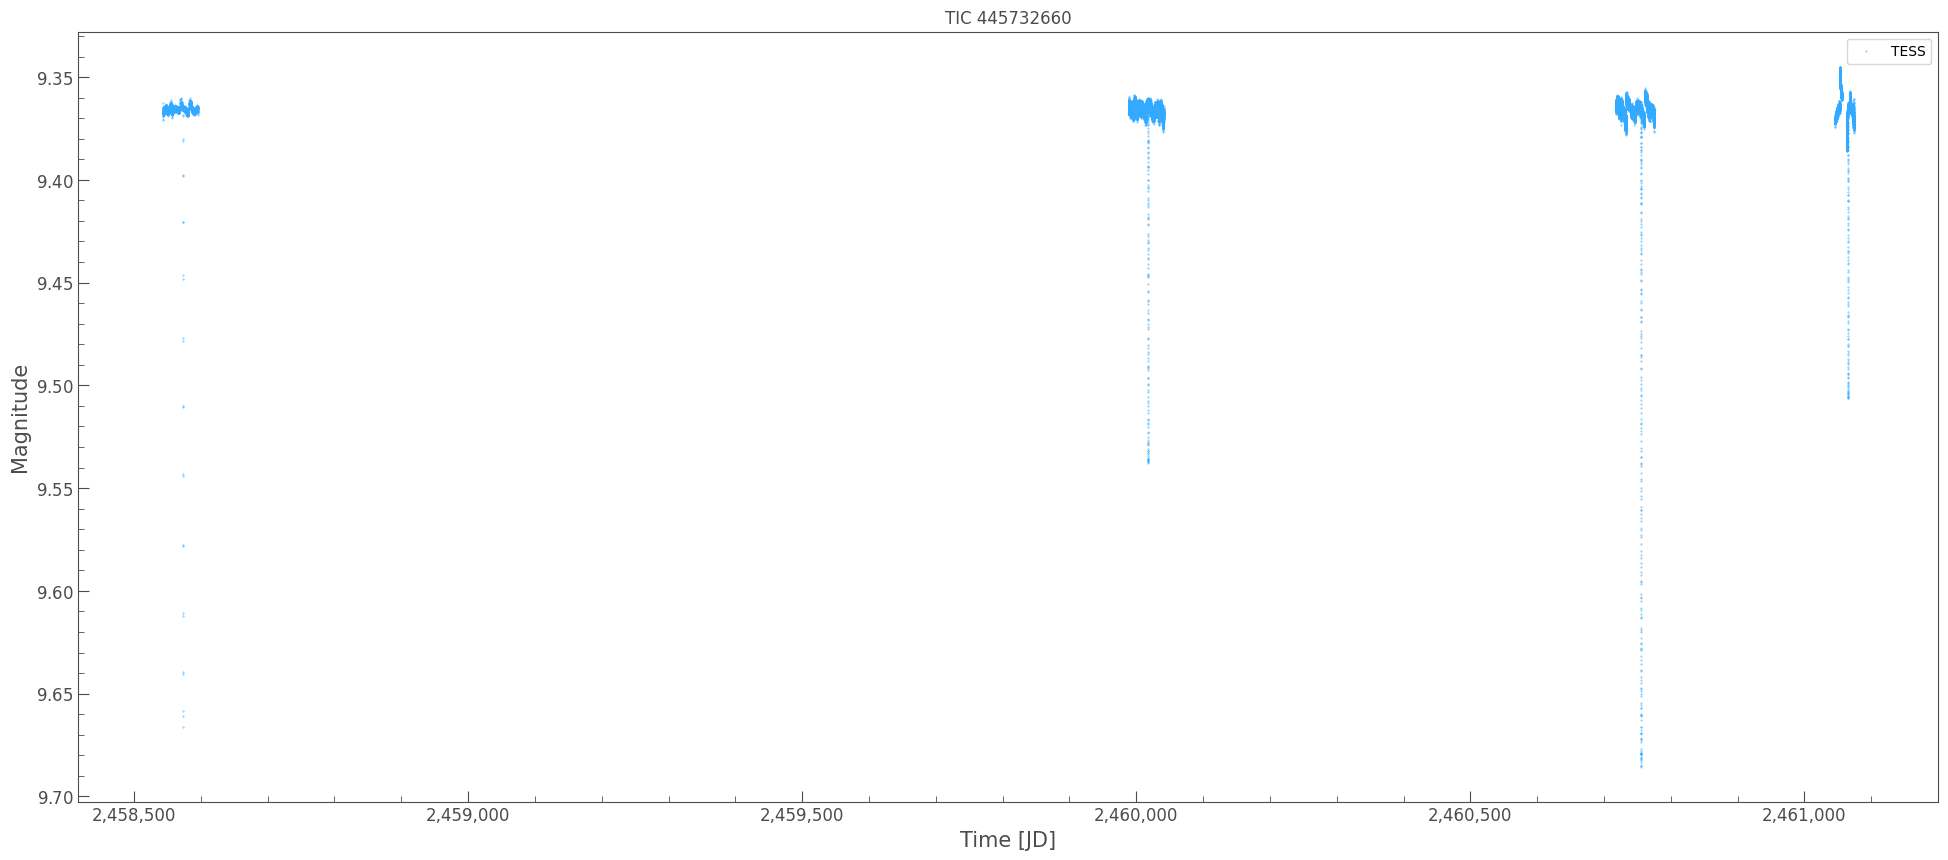

In [131]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



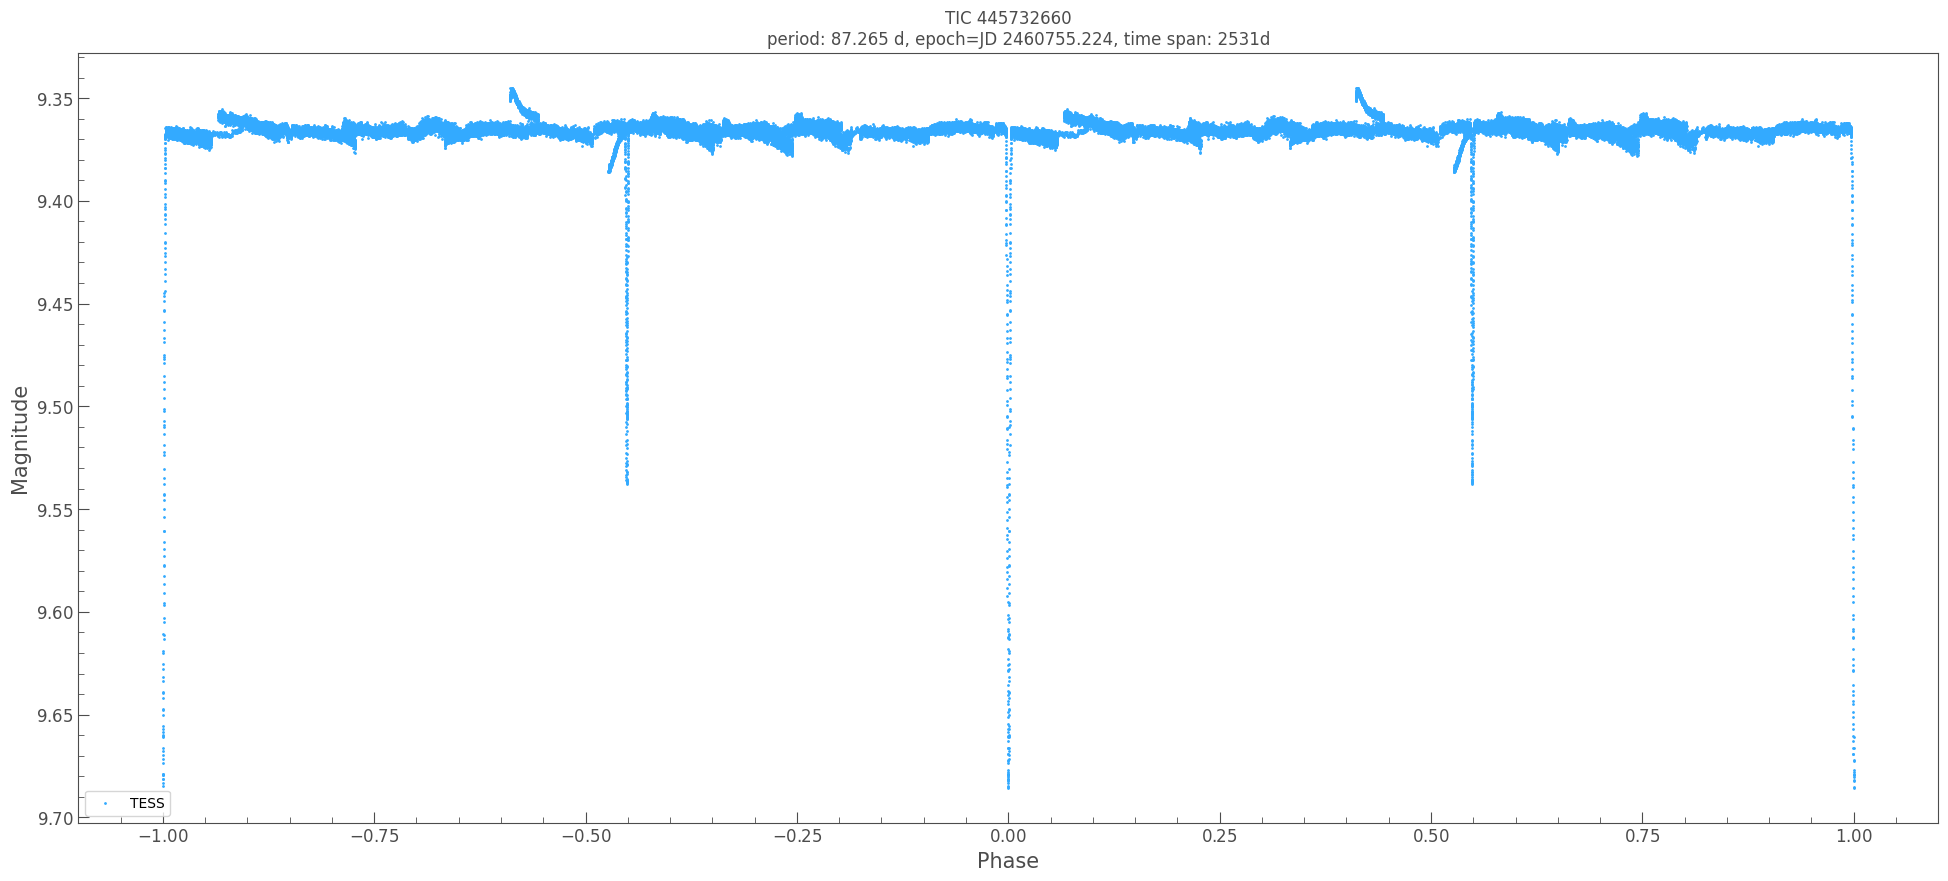

In [142]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", some systematics removed");


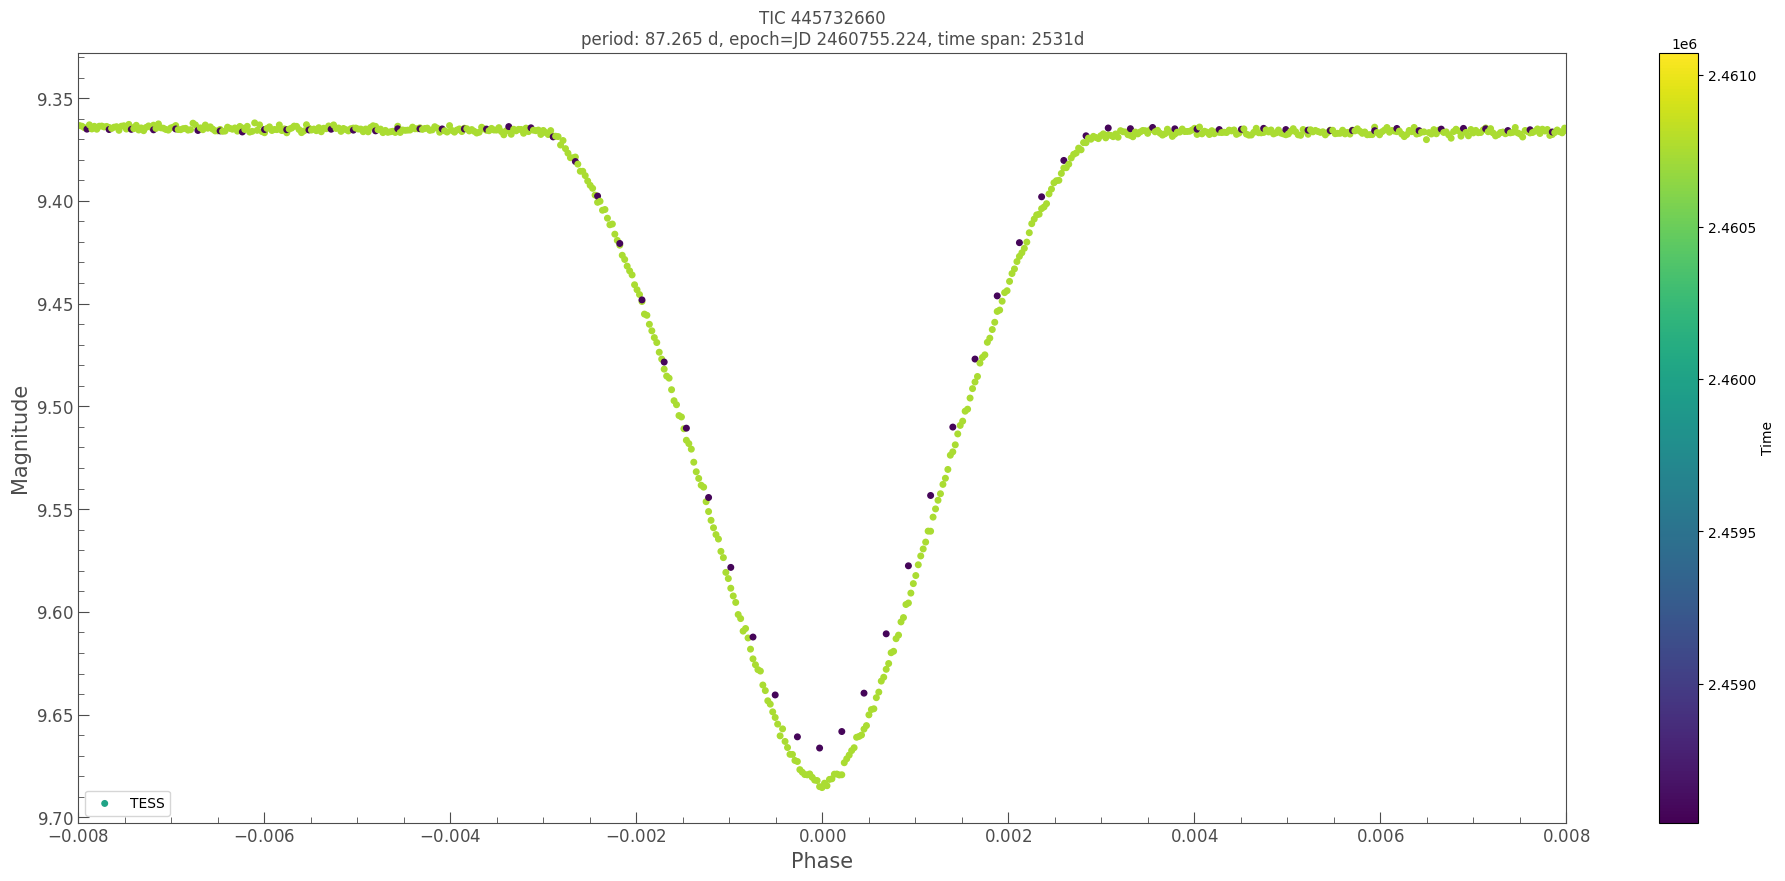

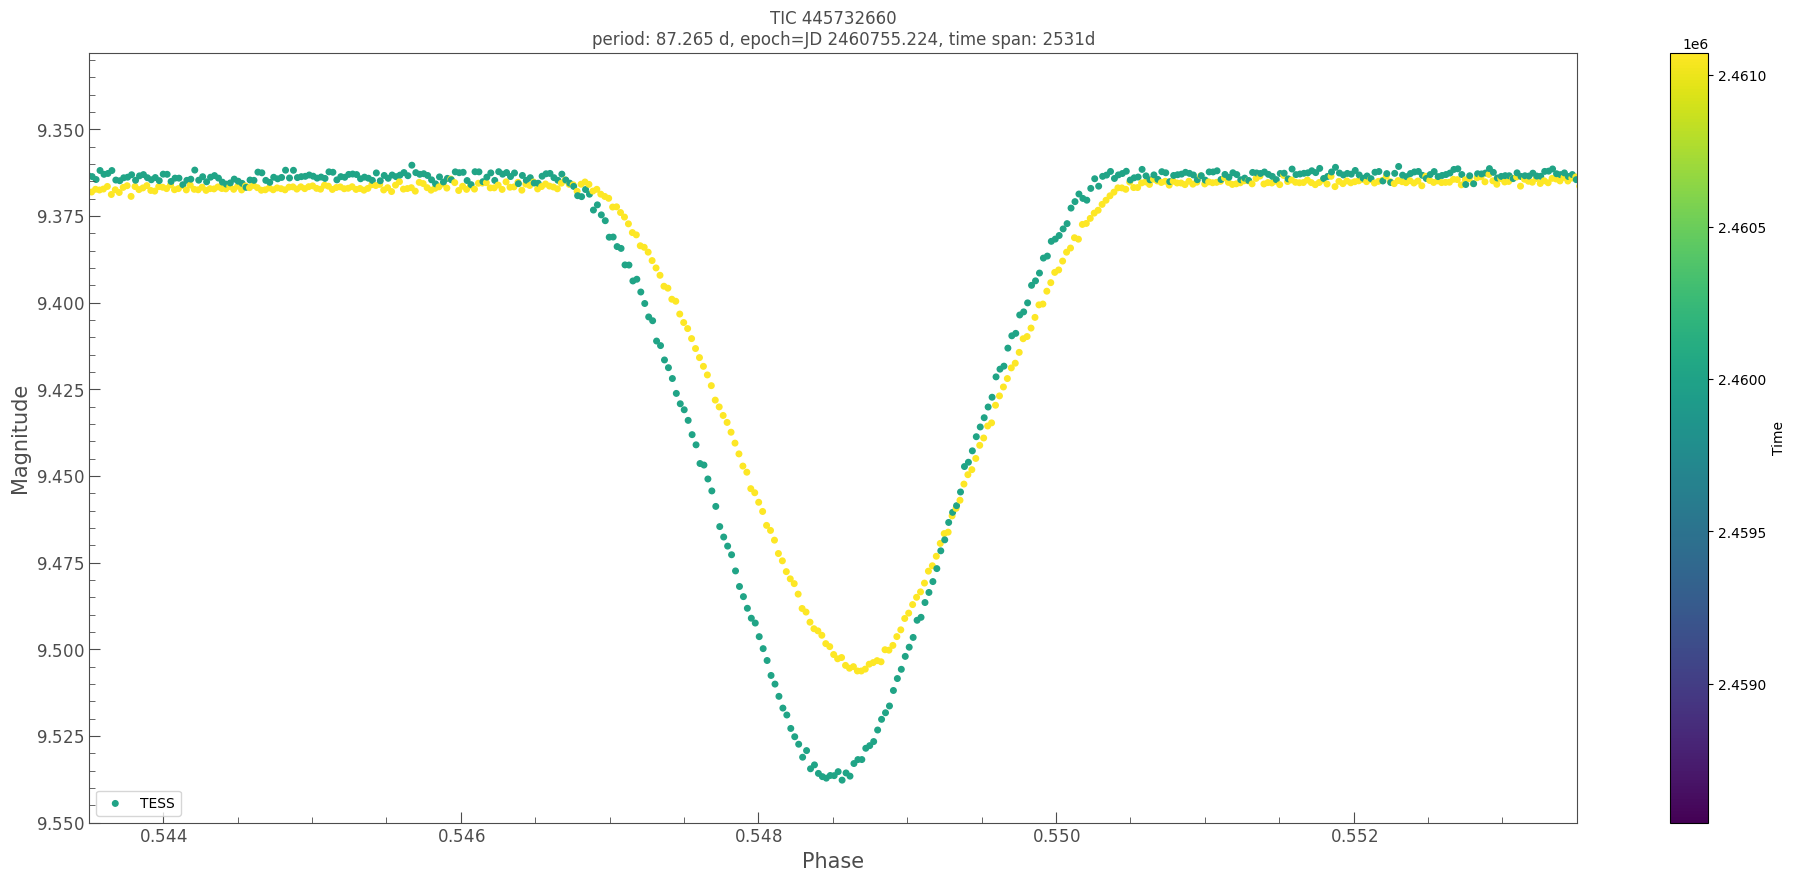

In [141]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=16, c="_time_"))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.008, 0.008);  # to see primary in details
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", some systematics removed");


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_ii_final ,  # for plotting only
    # duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.005, epoch_phase_min_ii_final + 0.005);  # to see secondary in details
ax.set_ylim(*ylim_min_ii);
# ax.set_title(ax.get_title() + ", some systematics removed");


### JD Plot (TESS)

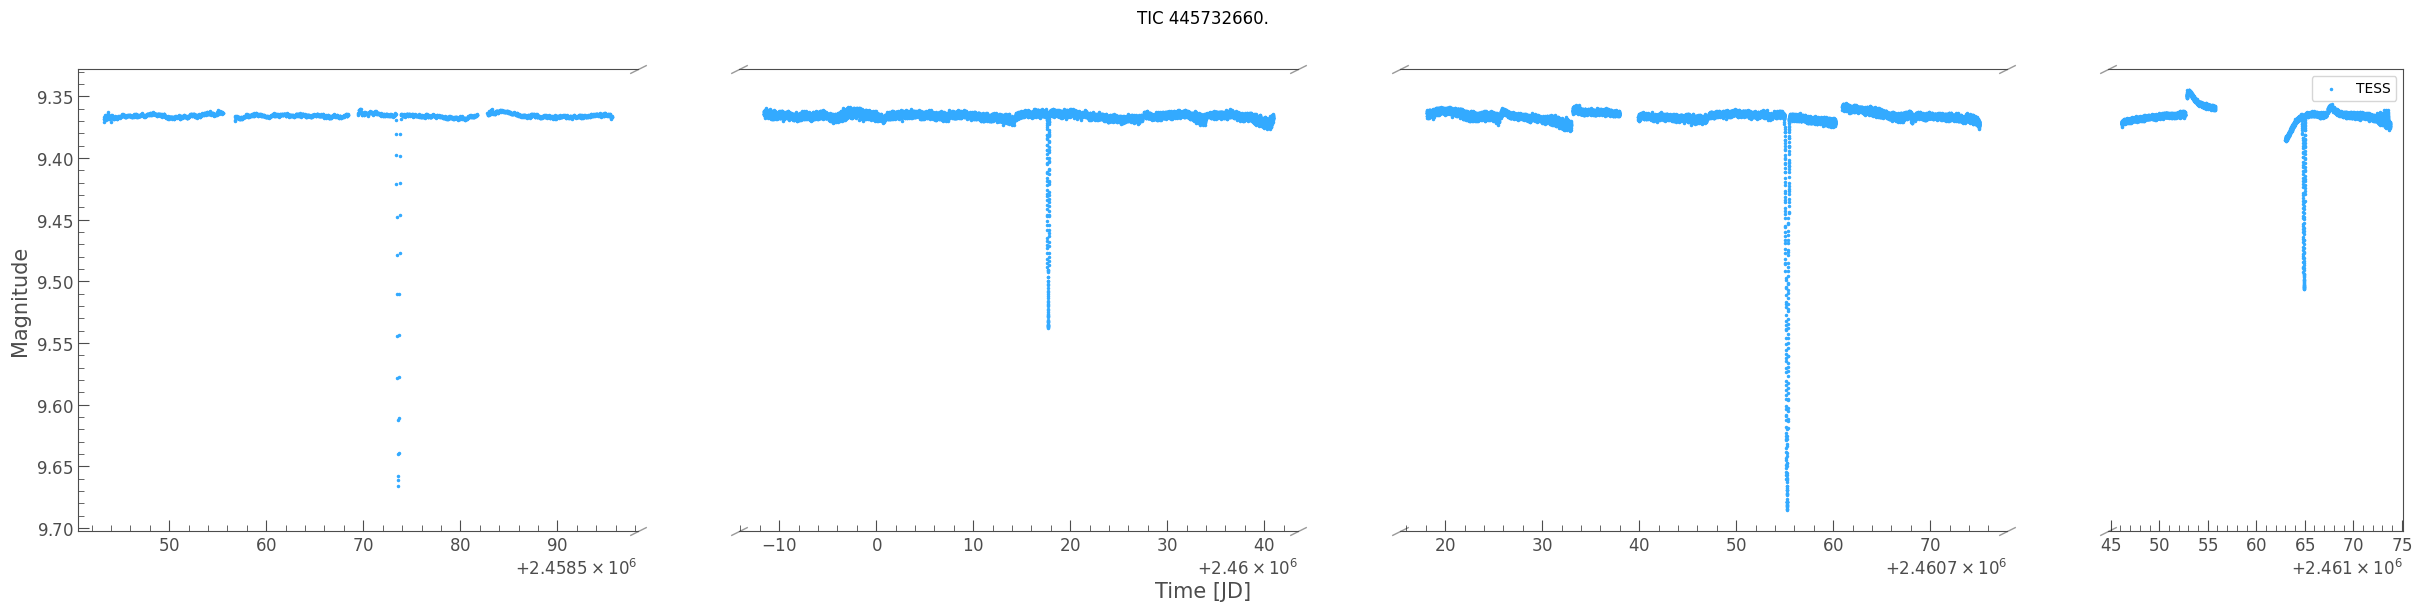

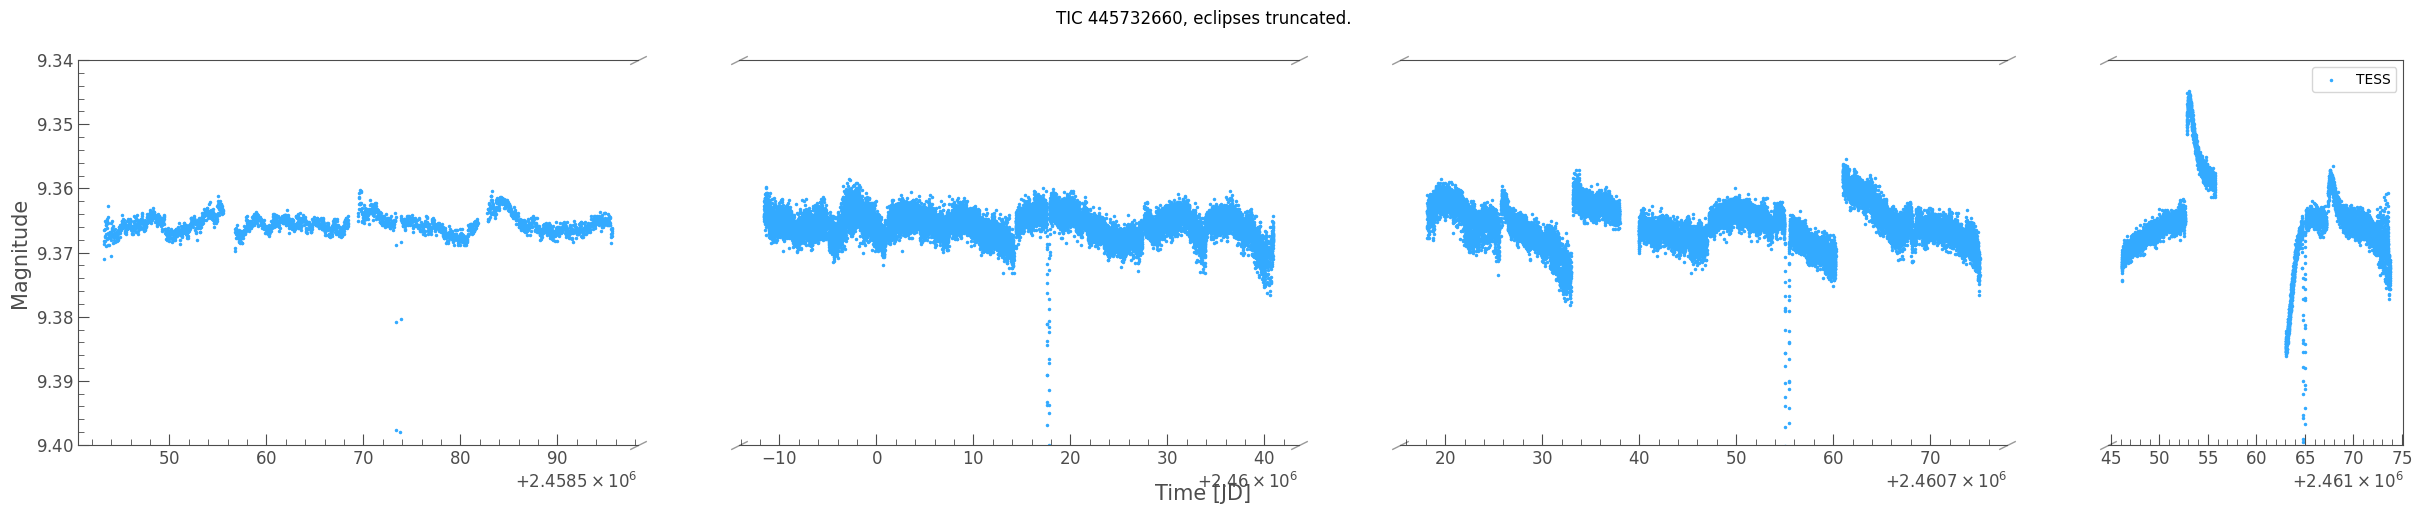

In [148]:
# # to shwo the eclipses and the time without eclipses
axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 6), s=9, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
axs[0].get_figure().suptitle(f"{primary_name}.");

axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 5), s=9, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
axs[0].get_figure().suptitle(f"{primary_name}, eclipses truncated.");
[ax.set_ylim(9.40, 9.34) for ax in axs];  # truncating Min I
# axs[-1].axhline(9.385, c="red", linestyle="--"); axs[-1].axhline(9.345, c="red", linestyle="--");   # to shoe the out of eclipse min/max
# Note: copy the 2 figures and save them as a single file (jpg)

## VSX Report Table

In [95]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [152]:
import bibs_utils
# reload(bibs_utils)
BIBS = bibs_utils.BIBS


other_names = "TYC 8193-1155-1,UCAC4 196-035446,2MASS J09484170-5058262" # in ExoFOP and SIMBAD
other_names +=",WISEA J094841.69-505825.8"  # ExoFOP + Vizier -- https://vizier.cfa.harvard.edu/viz-bin/VizieR-5?-ref=VIZ6a83596728b9f7&-out.add=.&-source=II/328/allwise&AllWISE===J094841.69-505825.8
other_names += ",CD-50 4533A,GSC 08193-01155,WDS J09487-5058A"  # other useful SIMBAD names


remarks = (
    f"""Eccentric system. Min II at phase {epoch_phase_min_ii_final}, amplitude {amp_min_ii_flux_mag} TESS, duration {100 * duration_hr_min_ii_final / 24 / float(period_final):.1f}%."""
    f""" Possible apsidal motion and eclipse depth variation."""
    f""" Out-of-eclipse variation of amplitude 0.04 TESS likely to be systematics."""
    f""" A quadruple system per 2023MNRAS.524.4296P: the eclipsing components denoted as Aa1 and Aa2, but they might be from Ab."""  # from a single eclipse in the paper; the EB are either Aa or Ab,  assumed to be Aa
    f""" The magnitude in the main table refers to the composite component A."""
)

# Params from 2023MNRAS.524.4296P Table 3: 
"""
MSC        Comp.      Type    Per     u  Sep   u Vmag1 Vmag2 M1     M2     Note
09487-5058 A,B,*      Cmp      7.6372 k  4.630 " 10.16 18.20 1.72 s 0.20 v DAM_1766, Gaia                
09487-5058 Aa,Ab,A    a,v     10.0317 y  0.054 " 10.77 11.07 0.88 s 0.84 v RUWE=2.3 SOAR dI=0.30
09487-5058 Aa1,Aa2,Aa e        0.0000 d  0.000 " 10.77  0.00 0.88 v 0.00   TIC 445732660, single eclipse
"""

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS data. Amplitude from TESS data.
revision_comment = f"Maximum magnitude derived from Gaia DR3. Spectral type from {BIBS.GAIA_DR3_ASTROPHY_B}. Gaia DR3 position."


vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="K",  # Gaia DR3 astrophysical
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{median_flux_vmag}",  # from Gaia DR3
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Period_Uncertain=False,
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / float(period_final):.1f}",  # 1 decimal point is enough visually
    # Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk: https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/subjects/88068752
    Discoverer="B. P. Powell et al. (TESS)",  # they IDed a single eclipse with no specifics
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.QLP_N,  
    Reference0_Bib=BIBS.QLP_B,
    Reference2_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    Reference2_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
    Reference3_Name="Powell, B. P.; et al., 2023, A Hunting Expedition For High-Order Hierarchies",
    Reference3_Bib="2023MNRAS.524.4296P",
    Reference4_Name="Multiple Star Catalog (online data)",
    Reference4_Link="https://astro.ulb.ac.be/msc/system/09487-5058/",
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic445732660_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data.
tic445732660_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min I.
tic445732660_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min II.
tic445732660_jd_plot_eclipses.jpg : TESS Lightcurve - Lightcurve from TESS QLP data.
""")


Other Names (1 line each):
TYC 8193-1155-1
UCAC4 196-035446
2MASS J09484170-5058262
WISEA J094841.69-505825.8
CD-50 4533A
GSC 08193-01155
WDS J09487-5058A

Eccentric system. Min II at phase 0.5485, amplitude 0.17 TESS, duration 0.4%. Possible apsidal motion and eclipse depth variation. Out-of-eclipse variation of amplitude 0.04 TESS likely to be systematics. A quadruple system per 2023MNRAS.524.4296P: the eclipsing components denoted as Aa1 and Aa2, but they might be from Ab. The magnitude in the main table refers to the composite component A.

Maximum magnitude derived from Gaia DR3. Spectral type from 2023A&A...674A..26C. Gaia DR3 position.


,Field,Value
0,Position,"147.17381, -50.97395"
1,Primary_Name,TIC 445732660
2,Other_Names,"TYC 8193-1155-1,UCAC4 196-035446,2MASS J09484170-5058262,WISEA J094841.69-505825.8,CD-50 4533A,GSC 08193-01155,WDS J09487-5058A"
3,Variable_Type,EA
4,Spectral_Type,K
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,10.18
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.32
9,Minimum_Magnitude_band,TESS



tic445732660_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data.
tic445732660_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min I.
tic445732660_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS QLP data. Zoomed around Min II.
tic445732660_jd_plot_eclipses.jpg : TESS Lightcurve - Lightcurve from TESS QLP data.

